In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import matplotlib.pyplot as plt

In [2]:
# LOAD DATA

df = pd.read_csv("temp_vanilla.csv")

X = df[
    [
        "temp_morning",
        "temp_afternoon",
        "temp_evening"
    ]
].values

y = df["next_day_temp"].values


In [3]:
# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
# SCALING

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)

y_train = y_scaler.fit_transform(
    y_train.reshape(-1,1)
)

y_test_scaled = y_scaler.transform(
    y_test.reshape(-1,1)
)


In [5]:
# RNN INPUT SHAPE

# Original:
# [morning afternoon evening]

# Convert to:
# (samples, timesteps, features)


X_train = X_train.reshape(
    X_train.shape[0],
    3,
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    3,
    1
)

In [6]:
# BUILD RNN MODEL

model = tf.keras.Sequential([

    tf.keras.layers.SimpleRNN(
        units=8,
        activation='tanh',
        input_shape=(3,1)
    ),

    tf.keras.layers.Dense(1)
])


In [7]:
# COMPILE

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss='mse',
    metrics=['mae']
)

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn (SimpleRNN)      (None, 8)                 80        
                                                                 
 dense (Dense)               (None, 1)                 9         
                                                                 
Total params: 89
Trainable params: 89
Non-trainable params: 0
_________________________________________________________________


In [9]:
# TRAIN
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)


Epoch 1/100
5/5 [==============================] - 0s 8ms/step - loss: 0.0871 - mae: 0.2346 - val_loss: 0.0724 - val_mae: 0.2061
Epoch 2/100
5/5 [==============================] - 0s 3ms/step - loss: 0.0867 - mae: 0.2341 - val_loss: 0.0729 - val_mae: 0.2037
Epoch 3/100
5/5 [==============================] - 0s 3ms/step - loss: 0.0865 - mae: 0.2342 - val_loss: 0.0736 - val_mae: 0.2016
Epoch 4/100
5/5 [==============================] - 0s 3ms/step - loss: 0.0869 - mae: 0.2355 - val_loss: 0.0745 - val_mae: 0.2016
Epoch 5/100
5/5 [==============================] - 0s 4ms/step - loss: 0.0869 - mae: 0.2352 - val_loss: 0.0745 - val_mae: 0.2012
Epoch 6/100
5/5 [==============================] - 0s 3ms/step - loss: 0.0869 - mae: 0.2351 - val_loss: 0.0742 - val_mae: 0.2011
Epoch 7/100
5/5 [==============================] - 0s 3ms/step - loss: 0.0869 - mae: 0.2352 - val_loss: 0.0738 - val_mae: 0.2038
Epoch 8/100
5/5 [==============================] - 0s 3ms/step - loss: 0.0865 - mae: 0.2348 - val

In [10]:
# PREDICTION

pred_scaled = model.predict(X_test)

predictions = y_scaler.inverse_transform(
    pred_scaled
)

actual = y_test.reshape(-1,1)


# EVALUATION

mse = mean_squared_error(
    actual,
    predictions
)

mae = mean_absolute_error(
    actual,
    predictions
)

rmse = np.sqrt(mse)

print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")


1/1 [==============================] - 0s 79ms/step
MSE  : 2.6320
RMSE : 1.6223
MAE  : 1.3741


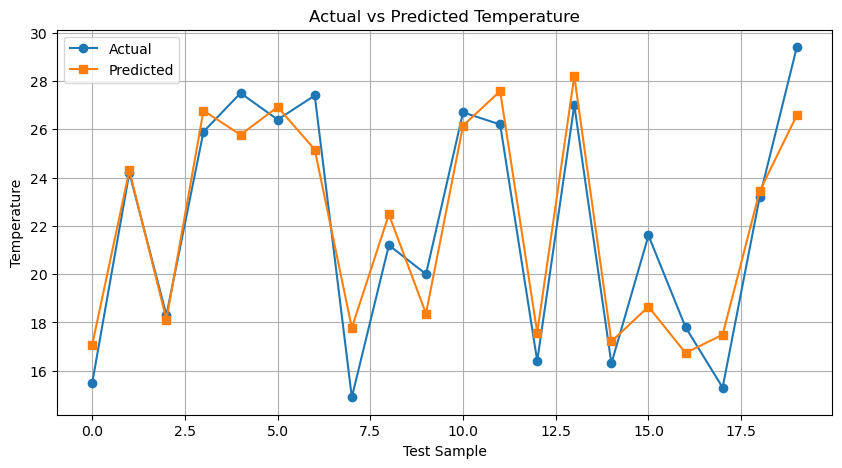

In [11]:
# PLOT

plt.figure(figsize=(10,5))

plt.plot(
    actual,
    marker='o',
    label='Actual'
)

plt.plot(
    predictions,
    marker='s',
    label='Predicted'
)

plt.title(
    "Actual vs Predicted Temperature"
)

plt.xlabel("Test Sample")
plt.ylabel("Temperature")

plt.grid(True)
plt.legend()

plt.show()